# Phase 1: Data Extraction & Exploratory Data Analysis
In this notebook, we utilize DuckDB to memory-efficiently extract the core ICU admission cohorts and their vitals from the massive `chartevents` CSV file. We then perform visual EDA on the extracted base database.

In [4]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Use the established database connection from Phase 1
DB_PATH = r"c:\Users\dell\Desktop\emergency-triage-systems\triage_system.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)

### 1. Extracted Cohort Summary

Total Cohort Size: 94,458 ICU Stays


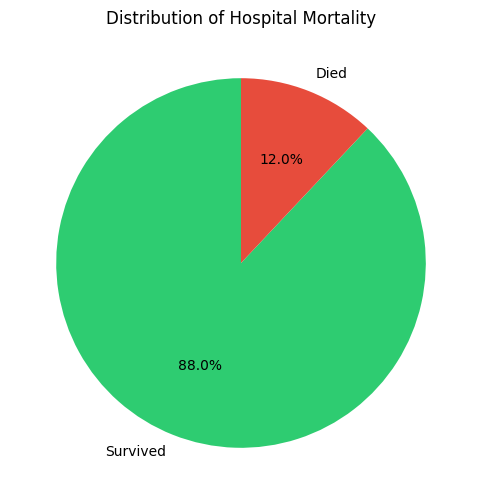

In [5]:
# Fetch the cohort demographics
cohort = con.execute("SELECT * FROM cohort").fetchdf()
print(f"Total Cohort Size: {cohort.shape[0]:,} ICU Stays")

# Cohort Mortality Rate Visualization
plt.figure(figsize=(6,6))
cohort['hospital_expire_flag'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Survived', 'Died'], colors=['#2ecc71', '#e74c3c'], startangle=90
)
plt.title("Distribution of Hospital Mortality")
plt.ylabel('')
plt.show()

### 2. Age Distribution

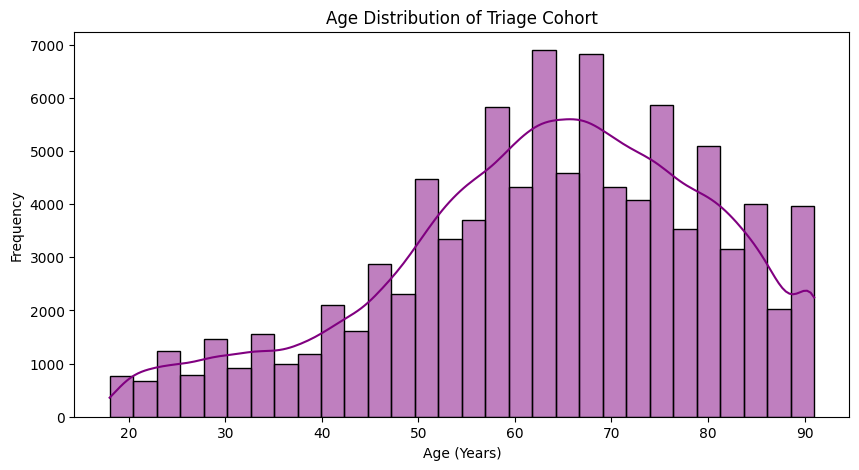

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(cohort['anchor_age'], bins=30, kde=True, color='purple')
plt.title("Age Distribution of Triage Cohort")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.show()

### 3. Captured Vitals (First 4 Hours)

In [7]:
# Look at the long-format vitals captured within the 4-hour simulated triage window
vitals_summary = con.execute('''
    SELECT itemid, COUNT(*) as readings 
    FROM triage_vitals_4h 
    GROUP BY itemid 
    ORDER BY readings DESC
''').fetchdf()
print(vitals_summary)
con.close()

   itemid  readings
0  220045    540406
1  220210    532034
2  220277    519571
3  220179    362567
4  220180    362482
5  220739    143440
6  223900    142995
7  223901    142324
8  223761    124780
9  223762     19953


### 4. Age vs. Mortality (Why age-based priority is insufficient)
In some triage systems, age is heavily weighted. However, let's visualize how mortality is distributed across ages. We will see that while older patients have higher risk, relying strictly on age would deprioritize many younger patients who are genuinely critical.

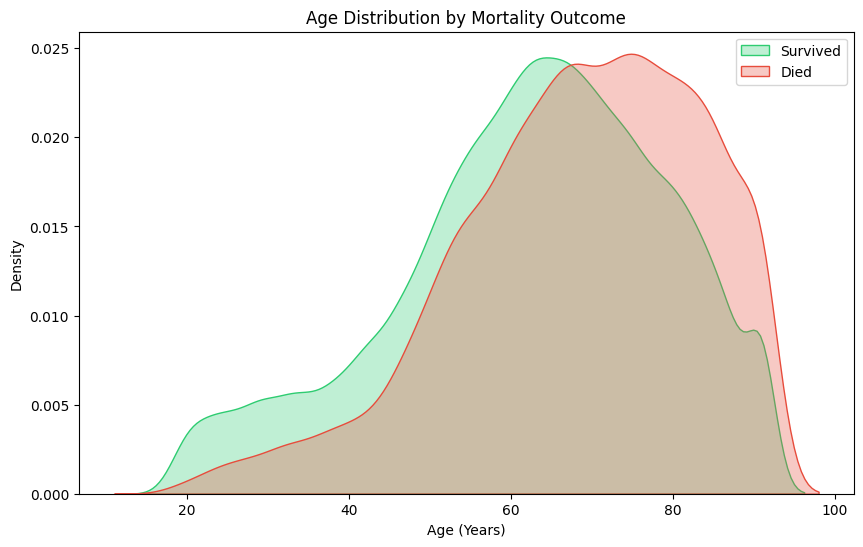

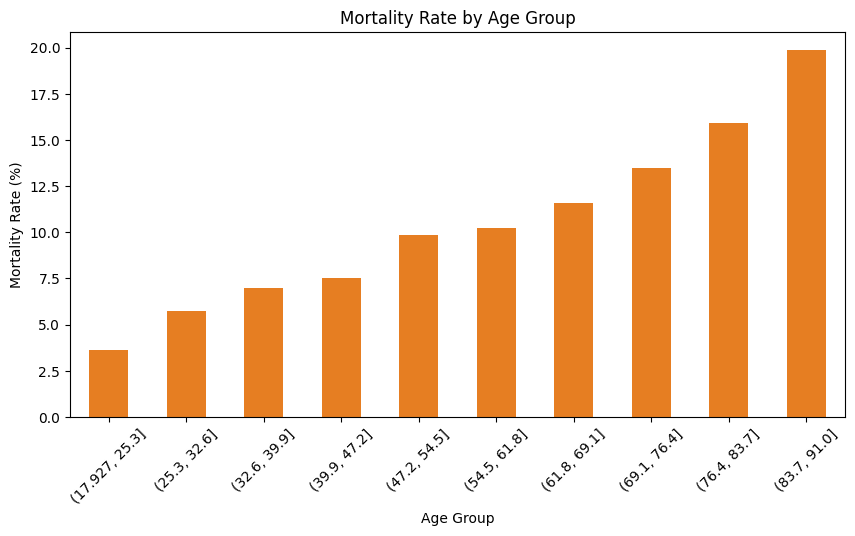

In [8]:
plt.figure(figsize=(10, 6))

# Plot age distribution separated by mortality
sns.kdeplot(data=cohort[cohort['hospital_expire_flag'] == 0], x='anchor_age', label='Survived', fill=True, color='#2ecc71', alpha=0.3)
sns.kdeplot(data=cohort[cohort['hospital_expire_flag'] == 1], x='anchor_age', label='Died', fill=True, color='#e74c3c', alpha=0.3)

plt.title("Age Distribution by Mortality Outcome")
plt.xlabel("Age (Years)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Alternative: Bar plot of mortality rate by age decile
cohort['age_group'] = pd.cut(cohort['anchor_age'], bins=10)
mortality_by_age = cohort.groupby('age_group')['hospital_expire_flag'].mean() * 100

plt.figure(figsize=(10, 5))
mortality_by_age.plot(kind='bar', color='#e67e22')
plt.title("Mortality Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mortality Rate (%)")
plt.xticks(rotation=45)
plt.show()